# ResoKit's Tutorial

This tutorial is a guide to use ResoKit package.
ResoKit is toolkit package for the analysis and diagnostics of resonances in exoplanetary planetary systems.

In this tutorial we show, step by step, how to get started with the ResoKit package.

---

## Import ResoKit and the necessary packages

In [1]:
import resokit

## Loading the data

The first step is to load an exoplanetary system. The available datasets are [NASA](https://exoplanetarchive.ipac.caltech.edu/) or [EU](https://exoplanet.eu/home/).
Both datasets are provided with the package, and they can be updated if necessary.

To load a system, functions `load_system_from_nasa` and `load_system_from_eu` are provided in the `io` module.

For this turorial, we will work with the  `Kepler-47` exoplanetary system, from the Exoplanet.eu dataset.

In [2]:
kepler47 = resokit.io.load_system_from_eu("Kepler-47")

Loading star system Kepler-47 from eu.
 Loading exoplanet_eu.csv directly from datasets.zip...
 Storing the index columns into memory...
Star Kepler-47 not found in eu dataset.
 Similar names found in eu dataset:
 - ['Kepler-47 A', 'Kepler-471', 'Kepler-472', 'Kepler-473', 'Kepler-474', 'Kepler-475', 'Kepler-476', 'Kepler-478', 'Kepler-479']


If the system (or star in this case) name is entered incorrectly, ResoKit will attempt to detect the intended system and provide suggestions based on it.
As Exoplanet.eu is indexed through star name, we see here that the correct system (star) name is `Kepler-47 A`.

In [3]:
kepler47 = resokit.io.load_system_from_eu("Kepler-47 A")

Loading star system Kepler-47 A from eu.
 Loading exoplanet_eu.csv directly from datasets.zip...


Now, `kepler47` is a Static System. We can see its components (star and planets) and where the system was obtained from.

In [4]:
kepler47

StaticSystem: 
 Star:
  Kepler-47 A 
 Planets:
  Kepler-47 (AB)b
  Kepler-47 (AB)d
  Kepler-47 (AB)c
 from 'eu' data source.

## Analysing the Static System

Some features we can apply to this System are:

- Planet inspection: `planet`
- Calculate period ratios: `period_ratios`
- Plot planet, star, of general system attributes: `plot`
- Remove or add a planet: `remove`, `add`
We will now explain how to use each of them.

### Inspection

We can access any planet (or even the system star) fromthe Static System.

For example, if we want to retrieve the 2nd planet (sorted by period), we simply do

In [5]:
planet2 = kepler47.planet(1) # Remember python is 0 indexed, so the second planet is "1".
planet2

StaticPlanet [Kepler-47 (AB)d] from eu data source.

We can display the planet properties as a Series.

In [6]:
planet2.data_df

name                                Kepler-47 (AB)d
mass_sin_i_err_max                              NaN
w                                             352.0
rowupdate                                2024-08-12
tperi                                           NaN
P_err_max                                      0.15
e                                             0.024
mass_err_min                                 0.0368
star_name                               Kepler-47 A
n_err_max                                 41.887902
a                                            0.6992
inc_err_max                                     NaN
mass_sin_i_err_min                              NaN
radius                                       0.6281
e_err_min                                     0.017
tperi_err_min                                   NaN
inc                                            90.0
reference             Published in a refereed paper
radius_err_min                               0.0437
n_err_min   

And we can acces any of this attributes.
For example the _name_, or the semi-major axis _a_:

In [7]:
planet2.name

'Kepler-47 (AB)d'

In [8]:
planet2.a

0.6992

### Calculate and plot (if possible) period ratios

If we want to obtain the period ratio between all pair of planets: $P_{i+1}/P_{i}$, we simply invoke Static System `period_ratios` property.

In [9]:
kepler47.period_ratios

,Kepler-47 (AB)b,Kepler-47 (AB)d,Kepler-47 (AB)c
Kepler-47 (AB)b,1.000000,3.783778,6.122470
Kepler-47 (AB)d,0.264286,1.000000,1.618084
Kepler-47 (AB)c,0.163333,0.618015,1.000000


Here we can see that $P_{Kepler-47 (AB)c} \sim 6.122470 P_{Kepler-47 (AB)c}$.

If we want to get the period ratios as fractions, we simply invoke Static System `pair_ratio` method, including (as a _fraction_kwargs_ dict) any `resokit.utils.float_to_fraction` fuction argument. For example: _max_error_ (which is the maximum relative error between the estimated fraction and the floating period ratio).

In [10]:
kepler47.pair_ratio("all", fraction_kwargs={'max_error': 1e-1})

,Kepler-47 (AB)b,Kepler-47 (AB)d,Kepler-47 (AB)c
Kepler-47 (AB)b,"(1, 1)","(4, 1)","(6, 1)"
Kepler-47 (AB)d,"(1, 4)","(1, 1)","(3, 2)"
Kepler-47 (AB)c,"(1, 6)","(2, 3)","(1, 1)"


Here, is more clear that $P_{Kepler-47 (AB)b}$ and $P_{Kepler-47 (AB)c}$ are somewhat _close_ to a $6/1$ mean motion resonance.
Moreover, we also see that $P_{Kepler-47 (AB)d}$ and $P_{Kepler-47 (AB)c}$ are somewhat _close_ to a $3/2$ mean motion resonance.

In case the errors (of the period ratio estimations) are needed, they can be obtained invoking Static System  `pair_ratio` method again, with `errors=True`.
They are calculated using each observed period error, so each value is an upper limit for the error.

In [11]:
kepler47.pair_ratio("all", error=True)

,Kepler-47 (AB)b,Kepler-47 (AB)d,Kepler-47 (AB)c
Kepler-47 (AB)b,0.001142,0.004304,0.005155
Kepler-47 (AB)d,0.000301,0.001132,0.001351
Kepler-47 (AB)c,0.000138,0.000516,0.000336


#### Plot

If the system has a _triplet_ (three planets or more), it can be plotted in a period ratios separations space: $P_{i+1}/P_{i}$ vs. $P_{i+2}/P_{i+1}$.
To do so, we invoke Static System `plot_triplet` method. Here, we also plot the errors.

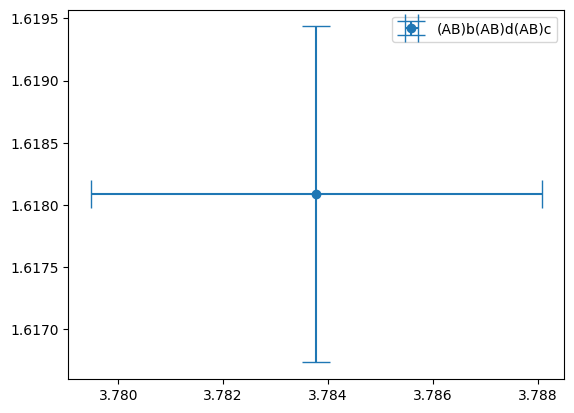

In [12]:
ax = kepler47.plot_triplet(error=True, capsize=10)
ax.legend()

### Plot

We can plot any pair atributes, of any planet in the system.

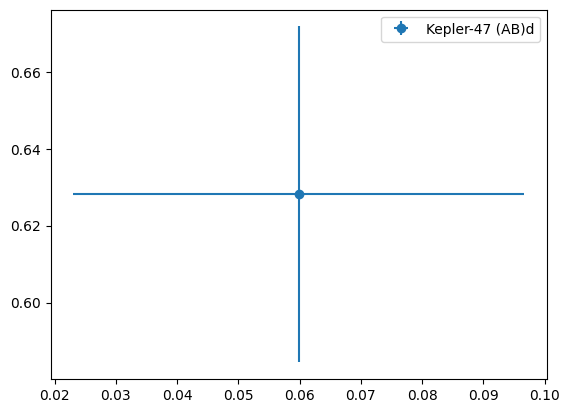

In [13]:
ax = kepler47.plot("mass", "radius", error_x=True, error_y=True)
ax.legend()

Some planets are not plotted because they do not have both requested attributes measured.

For example, in this case...

In [17]:
kepler47["radius"]

Kepler-47 (AB)b    0.2700
Kepler-47 (AB)d    0.6281
Kepler-47 (AB)c    0.4100
Name: radius, dtype: float64

We see the three planets have radius estimations; but...

In [18]:
kepler47["mass"]

Kepler-47 (AB)b        NaN
Kepler-47 (AB)d    0.05984
Kepler-47 (AB)c        NaN
Name: mass, dtype: float64

only `Kepler-47 (AB)d` has its mass estimated.

**EXTRA**

`ResoKit` also provides tools for mass (or radius) estimation with diverse models, from the estimated radius (or mass).

To do so, we simply use `estimate_mass` function.

In [19]:
kepler47["radius"].apply(resokit.utils.mass_radius.estimate_mass)

Kepler-47 (AB)b    0.008902
Kepler-47 (AB)d    0.183521
Kepler-47 (AB)c    0.039786
Name: radius, dtype: float64

Here we used the default `estimate_mass` parameters, but we can get different estimations with different models

In [23]:
for radius in kepler47["radius"]:
    print(resokit.utils.mass_radius.estimate_mass(radius, model="m24", method=3, error=True))

(0.00727926247222116, -0.0005725444730882729, 0.0007161807307743476)
(0.16599920421692282, -0.0051049910291232625, 0.00732109001314557)
(0.03419901896131999, -0.000678296890292189, 0.0011104967099294094)
